In [4]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# Importăm DOAR clasa de Dataset din fișierul nostru extern
from binary_dataset import BinaryRetinopathyDataset

print("=== 🚀 ÎNCĂRCARE DATE ȘI DATALOADERS ===")

# Calea ta către date
DATA_DIR = r'B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\eyepacs\eyepacs_binar'
IMG_SIZE = 300
BATCH_SIZE = 32 # Scade la 8 dacă iei eroare CUDA Out of Memory

# 1. Definim Transformările AICI, ca să le poți "tuna" ușor
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    # transforms.RandomHorizontalFlip(p=0.5),
    # transforms.RandomVerticalFlip(p=0.5),
    # transforms.RandomRotation(15),
    # transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Instanțiem Dataseturile
train_ds = BinaryRetinopathyDataset(os.path.join(DATA_DIR, 'train'), transform=train_transform)
val_ds   = BinaryRetinopathyDataset(os.path.join(DATA_DIR, 'val'), transform=test_transform)
test_ds  = BinaryRetinopathyDataset(os.path.join(DATA_DIR, 'test'), transform=test_transform)

# 3. Construim DataLoaderele
# FIX CRITIC WINDOWS: num_workers=0 previne "înghețarea" procesului la epoca 2!
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=8, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)

print(f"✅ DataLoaderele au fost create cu succes!")
print(f"Număr de batch-uri pe antrenament: {len(train_loader)}")

=== 🚀 ÎNCĂRCARE DATE ȘI DATALOADERS ===
✅ DataLoaderele au fost create cu succes!
Număr de batch-uri pe antrenament: 3021


In [5]:
# Select?m placa video
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"?? Antren?m pe: {device}")

# Configura?ie recomandat? pentru fine-tuning complet pe clasificarea binar?
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 1e-4
DROPOUT = 0.40
EARLY_STOPPING_PATIENCE = 5
FREEZE_BACKBONE_EPOCHS = 0  # 0 = fine-tuning complet; seteaz? 2-3 pentru primele epoci cu backbone ?nghe?at
USE_POS_WEIGHT = False

# === COMENTAT: Modelul Multi-Clas? (Stage 2) nu mai este folosit aici ===
# model_stage2 = build_resnet50(num_classes=4) 
# ...

# Ini?ializ?m EfficientNet-B3 (cu greut??i pre-antrenate pe ImageNet)
model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)

# Modific?m ultimul strat pentru clasificare binar? ?i ad?ug?m dropout pentru regularizare
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Sequential(
    nn.Dropout(p=DROPOUT),
    nn.Linear(num_features, 1)
)

model = model.to(device)

# Verific?m distribu?ia claselor, dar nu folosim pos_weight dac? setul binarizat este deja echilibrat
num_sanatosi = len(os.listdir(os.path.join(DATA_DIR, 'train', 'sanatos')))
num_bolnavi = len(os.listdir(os.path.join(DATA_DIR, 'train', 'bolnav')))
print(f"Clase Stage 1: sanatos={num_sanatosi}, bolnav={num_bolnavi}")

if USE_POS_WEIGHT:
    pos_weight = torch.tensor([num_sanatosi / max(num_bolnavi, 1)], dtype=torch.float32, device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    print(f"pos_weight activ: {pos_weight.item():.4f}")
else:
    criterion = nn.BCEWithLogitsLoss()
    print("pos_weight dezactivat: setul binarizat este tratat ca echilibrat.")

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

def set_backbone_trainable(model, trainable):
    for name, param in model.named_parameters():
        if not name.startswith("classifier"):
            param.requires_grad = trainable

if FREEZE_BACKBONE_EPOCHS > 0:
    set_backbone_trainable(model, False)
    print(f"Backbone ?nghe?at pentru primele {FREEZE_BACKBONE_EPOCHS} epoci.")

# Folosim AMP (Automatic Mixed Precision) pentru a stoarce maximul din placa video (merge mai repede)
scaler = torch.amp.GradScaler('cuda')

?? Antren?m pe: cuda
Clase Stage 1: sanatos=48332, bolnav=48332
pos_weight dezactivat: setul binarizat este tratat ca echilibrat.


In [6]:
EPOCHS = 30
best_val_loss = float("inf")
bad_epochs = 0

print("=== ?? ?NCEPERE ANTRENARE EFFICIENTNET-B3 (BINAR) ===")

for epoch in range(EPOCHS):
    if FREEZE_BACKBONE_EPOCHS > 0 and epoch == FREEZE_BACKBONE_EPOCHS:
        set_backbone_trainable(model, True)
        print("Backbone dezghe?at: continu?m fine-tuning complet.")

    model.train()
    train_loss = 0.0
    
    # Liste pentru a stoca predic?iile ?i etichetele reale de pe Train
    train_preds, train_targets = [], []
    
    # Loop de Antrenament
    for images, labels in tqdm(train_loader, desc=f"Epoca {epoch+1}/{EPOCHS} [TRAIN]"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        with torch.amp.autocast('cuda'):
            outputs = model(images).squeeze(1)
            loss = criterion(outputs, labels)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item() * images.size(0)
        
        # Extragem predic?iile curente pentru Train Accuracy (f?r? s? afect?m gradientul)
        with torch.no_grad():
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int()
            train_preds.extend(preds.cpu().numpy())
            train_targets.extend(labels.cpu().numpy())
            
    # Loop de Validare
    model.eval()
    val_loss = 0.0
    val_preds, val_targets = [], []
    
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoca {epoch+1}/{EPOCHS} [VAL]"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).squeeze(1)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            
            # Sigmoid pentru a transforma ie?irea ?n probabilitate (0-1)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int()
            
            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(labels.cpu().numpy())
            
    # Metrici
    avg_train_loss = train_loss / len(train_ds)
    avg_val_loss = val_loss / len(val_loader.dataset)
    
    # Calcul?m acurate?ea pentru ambele seturi
    train_acc = accuracy_score(train_targets, train_preds)
    val_acc = accuracy_score(val_targets, val_preds)
    
    # Scheduler-ul scade learning rate-ul dac? val_loss nu mai scade
    scheduler.step(avg_val_loss)
    
    print(f"Rezumat Epoca {epoch+1}: T_Loss: {avg_train_loss:.4f} | T_Acc: {train_acc:.4f} | V_Loss: {avg_val_loss:.4f} | V_Acc: {val_acc:.4f}")
    
    # Salv?m cel mai bun model ?i aplic?m EarlyStopping pe val_loss
    if avg_val_loss < best_val_loss - 1e-4:
        best_val_loss = avg_val_loss
        bad_epochs = 0
        torch.save(model.state_dict(), 'efficientnet_b3_binar_best.pth')
        print(f"?? Model nou salvat! (Val Loss: {best_val_loss:.4f}, Val Acc: {val_acc:.4f})")
    else:
        bad_epochs += 1
        print(f"F?r? ?mbun?t??ire pe val_loss: {bad_epochs}/{EARLY_STOPPING_PATIENCE}")
        if bad_epochs >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping: val_loss nu s-a ?mbun?t??it timp de {EARLY_STOPPING_PATIENCE} epoci.")
            break

if FREEZE_BACKBONE_EPOCHS > 0:
    set_backbone_trainable(model, True)

=== ?? ?NCEPERE ANTRENARE EFFICIENTNET-B3 (BINAR) ===


Epoca 1/30 [VAL]:   2%|▏         | 8/416 [00:31<26:43,  3.93s/it]  


RuntimeError: Caught RuntimeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\.venv\Lib\site-packages\torch\utils\data\_utils\worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
  File "b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\.venv\Lib\site-packages\torch\utils\data\_utils\fetch.py", line 57, in fetch
    return self.collate_fn(data)
           ~~~~~~~~~~~~~~~^^^^^^
  File "b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\.venv\Lib\site-packages\torch\utils\data\_utils\collate.py", line 401, in default_collate
    return collate(batch, collate_fn_map=default_collate_fn_map)
  File "b:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\.venv\Lib\site-packages\torch\utils\data\_utils\collate.py", line 215, in collate
    collate(samples, collate_fn_map=collate_fn_map)
    ~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^



🔍 EVALUARE PE SETUL DE TEST (Sănătoși vs Bolnavi 50-50)...


Testare: 100%|██████████| 416/416 [01:09<00:00,  5.97it/s]



📊 RAPORT DE CLASIFICARE FINAL (EfficientNet-B3):
              precision    recall  f1-score   support

 Sănătos (0)       0.77      0.76      0.76      6652
  Bolnav (1)       0.76      0.78      0.77      6652

    accuracy                           0.77     13304
   macro avg       0.77      0.77      0.77     13304
weighted avg       0.77      0.77      0.77     13304



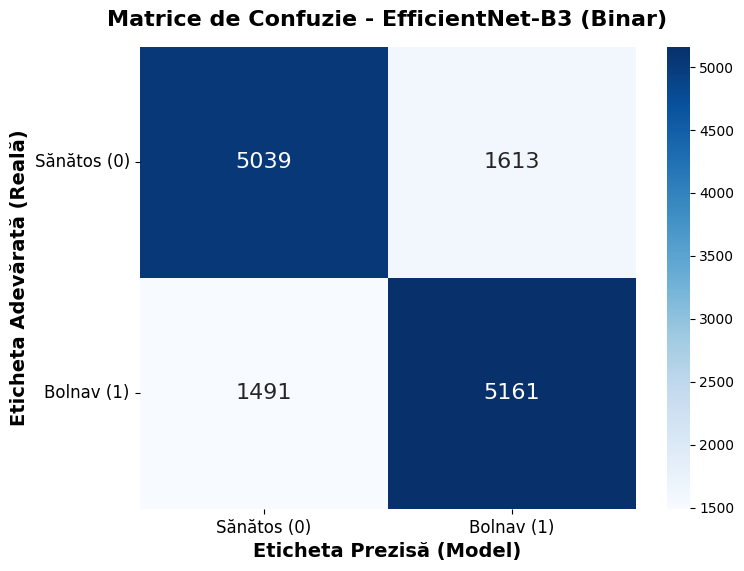

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

print("\n🔍 EVALUARE PE SETUL DE TEST (Sănătoși vs Bolnavi 50-50)...")

# Încărcăm cele mai bune greutăți găsite
model.load_state_dict(torch.load('efficientnet_b3_binar_best.pth'))
model.eval()

test_preds, test_targets = [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testare"):
        images = images.to(device)
        outputs = model(images).squeeze(1)
        
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.3).int()
        
        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(labels.numpy())

# 1. Printează raportul text clasic
print("\n📊 RAPORT DE CLASIFICARE FINAL (EfficientNet-B3):")
print(classification_report(test_targets, test_preds, target_names=['Sănătos (0)', 'Bolnav (1)']))

# 2. Calculăm și desenăm Matricea de Confuzie
cm = confusion_matrix(test_targets, test_preds)

plt.figure(figsize=(8, 6))
# Folosim o paletă de culori albastru (Blues) pentru un aspect profesional
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Sănătos (0)', 'Bolnav (1)'], 
            yticklabels=['Sănătos (0)', 'Bolnav (1)'],
            annot_kws={"size": 16}) # Font mai mare pentru numere

plt.title('Matrice de Confuzie - EfficientNet-B3 (Binar)', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Eticheta Adevărată (Reală)', fontsize=14, fontweight='bold')
plt.xlabel('Eticheta Prezisă (Model)', fontsize=14, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)

# Salvăm imaginea direct pe disc la rezoluție înaltă, perfectă pentru Word/LaTeX
plt.savefig('matrice_confuzie_binar.png', dpi=300, bbox_inches='tight')

plt.show()